In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super(AblationMLP, self).__init__()
        # flatten 32x32x3 -> 3072
        self.flatten = nn.Flatten()
        
        # manual linear layers: 3072 -> 1024 -> 512 -> 256 -> 10
        self.fc1 = nn.Linear(3072, 1024)
        self.bn1 = nn.BatchNorm1d(1024) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc4 = nn.Linear(256, 10)
        self.softmax = nn.Softmax(dim=1)
        
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
    
    def forward(self, x):
        x = self.flatten(x)
        
        # layer 1
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)
        
        # layer 2
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)
        
        # layer 3
        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)
        
        # output
        x = self.fc4(x)
        return x

In [4]:
# load full CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

100.0%
/Users/adel/Projects/Deep learning/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training set size: 50000
Test set size: 10000


In [ ]:
# setup device and hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.01
max_epochs = 20 # you can modify this according to hwat gpu you have 

# initialize model without regularization (no dropout, no batchnorm)
model = AblationMLP(use_dropout=False, use_batchnorm=False).to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Max Epochs: {max_epochs}")
print(f"Model: No Regularization (no dropout, no batchnorm)")

Device: cpu
Learning Rate: 0.01
Max Epochs: 20
Model: No Regularization (no dropout, no batchnorm)


In [6]:
def evaluate(model, dataloader, device):
    """compute accuracy on a dataloader"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    model.train()
    return accuracy

def train_epoch(model, train_loader, optimizer, loss_fn, device):
    """train for one epoch and return loss"""
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

In [7]:
# train the model for 20 epochs and track metrics
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(max_epochs):
    # train
    loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
    train_losses.append(loss)
    
    # evaluate
    train_acc = evaluate(model, train_loader, device)
    test_acc = evaluate(model, test_loader, device)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{max_epochs} | Loss: {loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("\nTraining completed!")
print(f"Final Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Generalization Gap: {train_accuracies[-1] - test_accuracies[-1]:.2f}%")

Epoch 1/20 | Loss: 2.1247 | Train Acc: 31.29% | Test Acc: 31.46%
Epoch 2/20 | Loss: 1.8309 | Train Acc: 38.74% | Test Acc: 39.06%
Epoch 3/20 | Loss: 1.6845 | Train Acc: 42.63% | Test Acc: 42.78%
Epoch 4/20 | Loss: 1.5927 | Train Acc: 45.38% | Test Acc: 45.37%
Epoch 5/20 | Loss: 1.5210 | Train Acc: 48.18% | Test Acc: 47.42%
Epoch 6/20 | Loss: 1.4585 | Train Acc: 49.56% | Test Acc: 47.76%
Epoch 7/20 | Loss: 1.4026 | Train Acc: 52.51% | Test Acc: 50.28%
Epoch 8/20 | Loss: 1.3525 | Train Acc: 53.67% | Test Acc: 50.47%
Epoch 9/20 | Loss: 1.3056 | Train Acc: 56.20% | Test Acc: 51.85%
Epoch 10/20 | Loss: 1.2623 | Train Acc: 57.28% | Test Acc: 51.92%
Epoch 11/20 | Loss: 1.2186 | Train Acc: 59.50% | Test Acc: 52.41%
Epoch 12/20 | Loss: 1.1792 | Train Acc: 60.75% | Test Acc: 52.29%
Epoch 13/20 | Loss: 1.1427 | Train Acc: 62.85% | Test Acc: 54.02%
Epoch 14/20 | Loss: 1.1057 | Train Acc: 63.39% | Test Acc: 52.83%
Epoch 15/20 | Loss: 1.0696 | Train Acc: 63.31% | Test Acc: 51.92%
Epoch 16/20 | Loss:

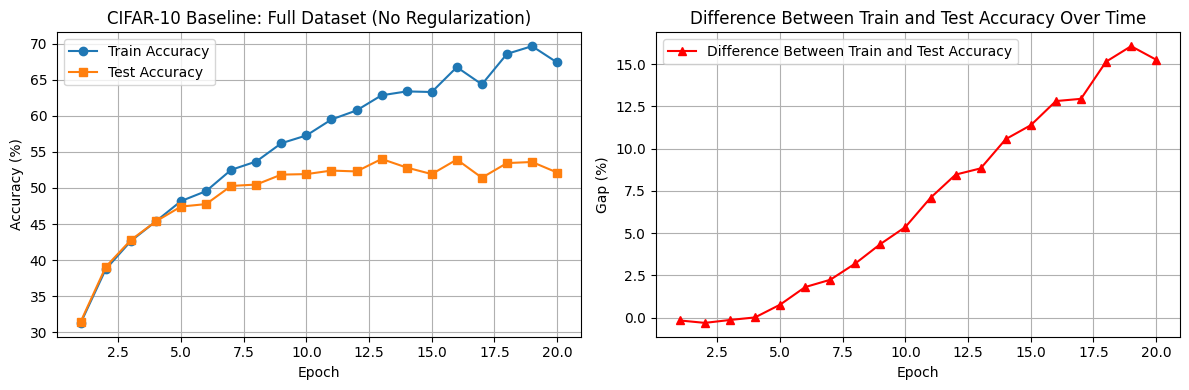

In [9]:
# visualize generalization gap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# plot accuracy curves
ax1.plot(range(1, max_epochs+1), train_accuracies, label='Train Accuracy', marker='o')
ax1.plot(range(1, max_epochs+1), test_accuracies, label='Test Accuracy', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('CIFAR-10 Baseline: Full Dataset (No Regularization)')
ax1.legend()
ax1.grid(True)

# plot generalization gap
gap = [train_accuracies[i] - test_accuracies[i] for i in range(max_epochs)]
ax2.plot(range(1, max_epochs+1), gap, label='Difference Between Train and Test Accuracy', marker='^', color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Gap (%)')
ax2.set_title('Difference Between Train and Test Accuracy Over Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

This is when no regularization ,early stopping,and noise is applied 
